In [102]:
!pip install pandas numpy gdown

In [103]:
import pandas as pd
import gdown

file_id = "1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O"

url = f"https://drive.google.com/uc?id={file_id}"

output = "processed_v2.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
df.head(5)

Downloading...
From: https://drive.google.com/uc?id=1Nv079uUCOAsO-cVQQ_UflV5xy9nkgZ6O
To: /content/processed_v2.csv
100%|██████████| 4.21M/4.21M [00:00<00:00, 19.1MB/s]


,title,text,category_id
0,Івано-Франківський драмтеатр знайшов архівні д...,{'clean': 'на пресконференції гендиректор-худо...,0
1,Премія Олеся Гончара оголосила номінантів,{'clean': 'Держмистецтв. Цьогоріч на здобуття ...,0
2,Біографічний фільм «Я граю Роккі» вийде у лист...,{'clean': ' The Hollywood Reporter. Стрічка ві...,0
3,Netflix підписав угоду на трансляцію фільмів S...,"{'clean': 'Deadline. Зазначається, що найважли...",0
4,На Венеційській бієнале Україну представить ск...,{'clean': 'розповіли учасники Венеційської біє...,0


In [104]:
file_id = "1ypHTyWvPif9MRipCdqlxELAup6hrvfYh"
url = f"https://drive.google.com/uc?id={file_id}"

output = "processed_v2_lemma.csv"
gdown.download(url, output, quiet=False)

df_lemma = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=1ypHTyWvPif9MRipCdqlxELAup6hrvfYh
To: /content/processed_v2_lemma.csv
100%|██████████| 7.28M/7.28M [00:00<00:00, 62.9MB/s]


In [105]:
import ast

def load_ids(file_id, filename):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", filename, quiet=False)
    with open(filename, "r") as f:
        ids = [int(line.strip()) for line in f]

    return ids

train_ids = load_ids("1t9vBXkyuP3a_Mkp52E2xb4Z3fm-ee78k", "train.txt")
val_ids = load_ids("1tkKDJxxeXaiQIUzYb9b0T0CARwG3SnSw", "val.txt")
test_ids = load_ids("1e1P2W-ktB5NlKiJkKUr9rJqnS5SCVH6A", "test.txt")

X_train = df.loc[train_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])
X_val = df.loc[val_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])
X_test = df.loc[test_ids, "text"].apply(lambda x: ast.literal_eval(x)["clean"])

y_train = df.loc[train_ids, "category_id"]
y_val = df.loc[val_ids, "category_id"]
y_test = df.loc[test_ids, "category_id"]

X_train_lemma = df_lemma.loc[train_ids, "lemma_text"]
X_val_lemma = df_lemma.loc[val_ids, "lemma_text"]
X_test_lemma = df_lemma.loc[test_ids, "lemma_text"]

y_train_lemma = df_lemma.loc[train_ids, "category_id"]
y_val_lemma = df_lemma.loc[val_ids, "category_id"]
y_test_lemma = df_lemma.loc[test_ids, "category_id"]


Downloading...
From: https://drive.google.com/uc?id=1t9vBXkyuP3a_Mkp52E2xb4Z3fm-ee78k
To: /content/train.txt
100%|██████████| 2.24k/2.24k [00:00<00:00, 4.30MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tkKDJxxeXaiQIUzYb9b0T0CARwG3SnSw
To: /content/val.txt
100%|██████████| 472/472 [00:00<00:00, 1.74MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e1P2W-ktB5NlKiJkKUr9rJqnS5SCVH6A
To: /content/test.txt
100%|██████████| 491/491 [00:00<00:00, 1.19MB/s]


In [106]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

def run_experiment(X_train, X_test, y_train, y_test):

    ukr_stopwords = [
        "про", "що", "та", "для", "це", "як", "але", "або", "він", "ми",
        "щоб", "році", "року", "бути", "стати", "щодо", "його", "які",
        "на", "2025", "сказав", "який", "від", "також", "лютого", "про це",
        "місце", "серед", "те", "2026", "зокрема" "пам", "рік",
    ]

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1,2),
            max_features=30000,
            min_df=3,
            stop_words=ukr_stopwords
        )),
        ("clf", LogisticRegression(max_iter=500, n_jobs=-1))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]

    errors_df = pd.DataFrame({
        "text": X_test,
        "gold_label": y_test,
        "predicted_label": y_pred,
        "comment": ""
    })
    errors_df = errors_df[errors_df["gold_label"] != errors_df["predicted_label"]]
    errors_df = errors_df.reset_index().rename(columns={"index": "text_id"})

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred)
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Classification report:\n", report)
    print("\n")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Прогнозований клас")
    plt.ylabel("Справжній клас")
    plt.title("Confusion matrix")
    plt.tight_layout()
    plt.show()


    return acc, macro_f1, report, vectorizer, clf, errors_df




Accuracy: 0.96
Macro F1: 0.9598660472319009
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        63
           1       1.00      0.98      0.99        63
           2       0.92      0.95      0.94        62
           3       0.93      0.92      0.93        62

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250





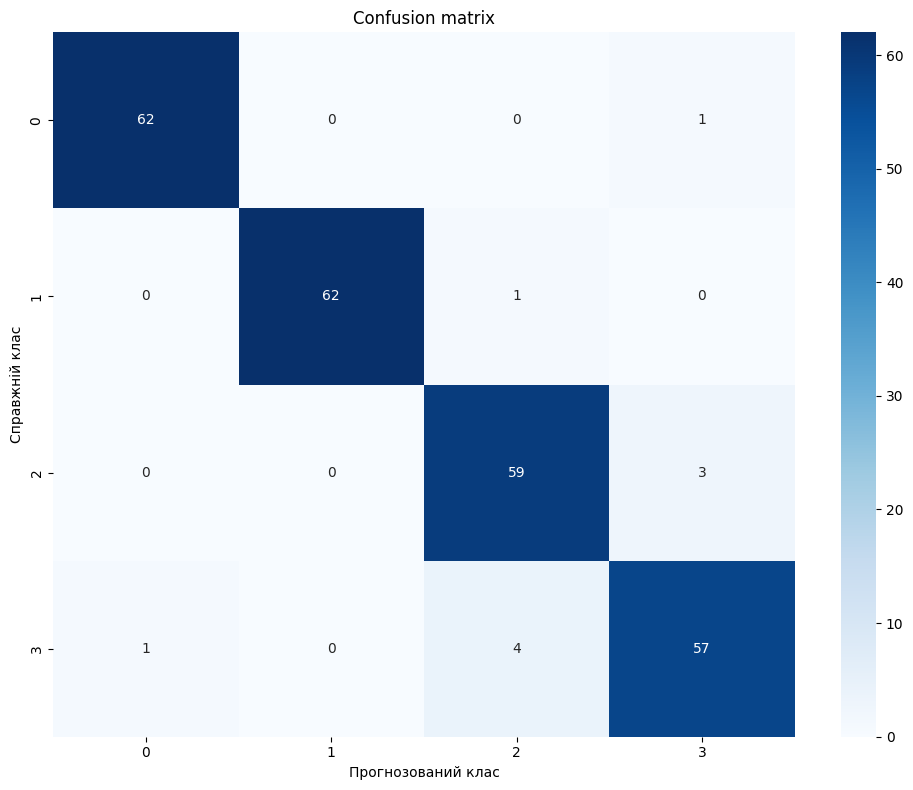

In [107]:
acc, macro_f1, report, vectorizer, clf, errors_df = run_experiment(
    X_train, pd.concat([X_test, X_val]),
    y_train, pd.concat([y_test, y_val])
)


Accuracy: 0.96
Macro F1: 0.9602176375278031
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        63
           1       1.00      0.97      0.98        63
           2       0.92      0.97      0.94        62
           3       0.92      0.95      0.94        62

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250





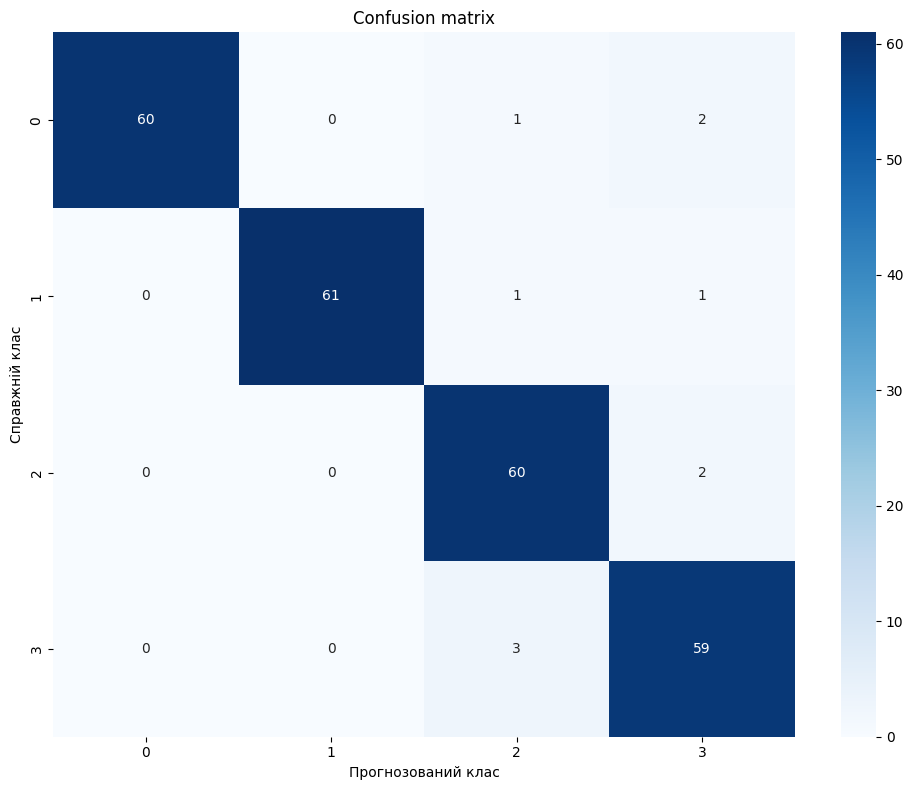

In [108]:
acc_lemma, macro_f1_lemma, report_lemma, _, _, _ = run_experiment(
    X_train_lemma, pd.concat([X_test_lemma, X_val_lemma]),
    y_train_lemma, pd.concat([y_test_lemma, y_val_lemma])
)


Для даного корпусу новин не спостерігається суттєвої різниці в якості класифікації між використанням обробленого тексту (processed text) та лематизованого тексту (lemma text), оскільки обидва підходи демонструють подібні значення метрик accuracy та macro-F1.

In [109]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

classes = clf.classes_

for i, class_label in enumerate(classes):
    print(f"\n-------- Клас: {class_label} --------")

    coefs = clf.coef_[i]
    top_positive_idx = np.argsort(coefs)[-10:][::-1]
    print("\nТоп-10 позитивних фіч:")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]}: {coefs[idx]:.4f}")

    top_negative_idx = np.argsort(coefs)[:10]
    print("\nТоп-10 негативних фіч:")
    for idx in top_negative_idx:
        print(f"{feature_names[idx]}: {coefs[idx]:.4f}")


-------- Клас: 0 --------

Топ-10 позитивних фіч:
культури: 1.4184
фільм: 1.3802
спадщини: 0.9973
фільму: 0.9645
номінації: 0.8884
євробачення: 0.8828
премії: 0.8751
культурної: 0.8638
видавництво: 0.7960
культурної спадщини: 0.7163

Топ-10 негативних фіч:
грн: -0.6882
зеленський: -0.5648
міністр: -0.5143
єс: -0.5115
млн: -0.4803
президент: -0.4763
україна: -0.4540
енергетики: -0.4418
оборони: -0.4389
україни: -0.4236

-------- Клас: 1 --------

Топ-10 позитивних фіч:
матчі: 1.0663
змагань: 1.0123
спорту: 0.8972
олімпійських: 0.8278
спорт: 0.8176
ігор: 0.7935
спортсменів: 0.7824
динамо: 0.7471
кубка: 0.7032
іграх: 0.6826

Топ-10 негативних фіч:
грн: -0.6894
сша: -0.5718
україни: -0.5340
млн: -0.5285
україні: -0.5059
зокрема: -0.4973
фільм: -0.4933
млрд: -0.4580
оборони: -0.4432
фейсбуці: -0.4227

-------- Клас: 2 --------

Топ-10 позитивних фіч:
грн: 1.8316
млн: 1.1845
енергетики: 0.8887
шмигаль: 0.8142
нафти: 0.8090
млрд: 0.7225
ринку: 0.7144
ціни: 0.6984
тис: 0.6896
повідомленні: 0.

## Аналіз фіч
Усі виділені слова та біграми виглядають логічно й відповідають тематиці відповідних класів: позитивні ознаки характеризують цільовий клас, негативні — пов’язані з іншими темами.

Під час першого запуску експерименту було виявлено наявність службових слів («про», «що», «то», «для», «він»), що свідчило про некоректне видалення стоп-слів. Для усунення цієї проблеми до TfidfVectorizer було додано список стоп-слів для української мови.

У фінальній моделі підозрілих токенів, таких як службові слова, технічні поля або назви джерел, не виявлено, що свідчить про відсутність leakage. Водночас спостерігається наявність загальноновинної лексики («Україна», «президент», «грн»), яка може відображати особливості корпусу (bias), однак не має критичного впливу на якість класифікації.

In [110]:
errors_df.head(10)

,text_id,text,gold_label,predicted_label,comment
0,15,"LRT. Моргенштерна було включено до списку ""не...",0,3,
1,267,"на сайті УЄФА. Зазначається, що вперше за всю ...",1,2,
2,474,заявила єврокомісарка з питань розширення Март...,2,3,
3,781,"""Попри складну внутрішньополітичну ситуацію у ...",3,2,
4,715,представниця пресслужби Вищого антикорупційног...,3,2,
5,594,"""Палата представників США ухвалила резолюцію п...",2,3,
6,423,"Відповідне рішення підтримали 458 депутатів, 1...",2,3,
7,644,Відповідний указ №100/2026 оприлюднено на сайт...,3,2,
8,742,міністр внутрішніх справ Ігор Клименко у Телег...,3,2,
9,764,"пресслужба секретаріату ЦВК. ""До Центральної в...",3,0,


In [111]:
df.rename(columns={'index': 'text_id'}, inplace=True)

errors_df.loc[errors_df["text_id"] == 15 , "comment"] = "У новині описується заборона пісень та концертів виконавця з міркувань державної безпеки. Політичний контекст домінує над культурним, що зумовлює помилкову класифікацію."
errors_df.loc[errors_df["text_id"] == 267, "comment"] = "Новина містить інформацію про доходи УЄФА та значну кількість фінансових показників. Через домінування економічної лексики модель класифікує текст як економічний, незважаючи на його спортивний контекст."
errors_df.loc[errors_df["text_id"] == 474, "comment"] = "У тексті присутні економічні показники, проте вони використовуються в межах опису політичних рішень. Модель орієнтується на політичний контекст та ігнорує фінансові ознаки."
errors_df.loc[errors_df["text_id"] == 781, "comment"] = "Новина акцентує увагу на обсягах гуманітарної та фінансової допомоги, тоді як інформація про країну-донор представлена менш виразно. Це зумовлює зміщення класифікації в бік економічної тематики."
errors_df.loc[errors_df["text_id"] == 715, "comment"] = "У тексті наявна значна кількість числових і фінансових показників (зокрема суми застави), які мають велику вагу серед ознак. Це призводить до помилкової класифікації як економічного тексту замість політико-правового."
errors_df.loc[errors_df["text_id"] == 594, "comment"] = "Новина містить численні політичні маркери (згадки про Конгрес, Дональда Трампа, наркотрафік), які переважають економічну складову (тарифи), що впливає на рішення моделі."
errors_df.loc[errors_df["text_id"] == 423, "comment"] = "У тексті домінують політичні маркери (ЄС, Україна, Комісія), які мають більшу вагу порівняно з економічними ознаками, що зумовлює відповідну класифікацію."
errors_df.loc[errors_df["text_id"] == 644, "comment"] = "Текст є занадто коротким і не містить достатньої кількості інформативних ознак для коректної класифікації."
errors_df.loc[errors_df["text_id"] == 742, "comment"] = "У новині переважають політичні маркери, які затьмарюють основну тему транспортного сполучення (пасажирського і вантажного), що призводить до помилки класифікації."
errors_df.loc[errors_df["text_id"] == 764, "comment"] = "У тексті відсутні “сильні” політичні маркери, що ускладнює віднесення до відповідного класу та призводить до помилкової класифікації."

errors_df.to_json("error_cases_lab6.jsonl", orient="records", lines=True, force_ascii=False)

## Категоризація помилок
**1. Overlap класів (змішана тематика)**

Текст містить ознаки одразу кількох класів, і модель обирає той, де ознаки мають більшу вагу.

* 15 - політика + культура
* 267 - спорт + економіка
* 474 - політика + економіка

**2. Домінування сильних маркерів (feature bias)**

Окремі слова (грн, млн, політичні імена) мають занадто велику вагу і “перетягують” класифікацію.

* 715 - фінансові показники -> економіка
* 594 - політичні імена/інституції -> політика
* 423 - ЄС/Україна -> політика

**3. Бракує контексту / потрібні n-грами**

Модель не вловлює фрази як єдину сутність.

* 474 - політичні рішення з економічними термінами
* 781 - гуманітарна допомога як складена концепція

**4. Короткий або недостатньо інформативний текст**

* 644 - замало ознак для впевненого рішення

**5. Відсутність ключових маркерів класу (rare/missing signals)**

* 764 - немає “сильних” політичних маркерів



Найчастіше зустрічаються помилки типу **overlap класів** та **домінування сильних маркерів**, що свідчить про складність текстів із змішаною тематикою та залежність моделі від окремих вагомих слів. Також помітною є проблема недостатнього врахування контексту, особливо для складених понять.

У першу чергу доцільно покращити обробку ознак: додати або посилити використання n-грам (біграм), щоб модель краще розпізнавала сталі словосполучення. Другим кроком варто зменшити вплив надто частих або “сильних” маркерів (наприклад, числових показників чи політичних назв), щоб уникнути зміщення класифікації.

Найбільший приріст якості, ймовірно, дасть саме врахування контексту через n-грами та часткове балансування ознак, оскільки це допоможе краще розрізняти тексти зі змішаною тематикою.

In [112]:
report = f"""# Audit Summary — Lab 6 (TF-IDF + Logistic baseline)

## Задача

**Тип задачі:** А — класифікація текстів (тема/тональність/спам/urgency)

## Стратегія split

Для корпусу новин використано комбіновану стратегію split: `Group + Time-based`.
1. Дані групуються за категорією новин (category_id).
2. Усередині кожної категорії новини сортуються за датою публікації (datePublished).
3. Після цього дані розділяються на:
* train — 70%
* validation — 15%
* test — 15%
Такий підхід дозволяє:
* уникнути temporal leakage (інформації з майбутнього у train);
* зберегти представлення всіх категорій у кожному спліті.

## Baseline 1: processed text

Accuracy: {acc}
Macro-F1: {macro_f1}
Classification report\n: {report}

## Baseline 2: lemma text

Accuracy: {acc_lemma}
Macro-F1: {macro_f1_lemma}
Classification report\n: {report_lemma}

## Чи був приріст і від чого

Після додавання до `TfidfVectorizer` списку стоп-слів для української мови було виявлено підвищення якості моделі: значення accuracy зросло з 0.944 до 0.96. Це пояснюється зменшенням впливу службових слів, які не несли значущої семантичної інформації та створювали шум у даних.

## 3 найтиповіші категорії помилок

1. Overlap класів (змішана тематика)
Текст містить ознаки одразу кількох класів, і модель обирає той, де ознаки мають більшу вагу.
2. Домінування сильних маркерів (feature bias)
Окремі слова (грн, млн, політичні імена) мають занадто велику вагу і “перетягують” класифікацію.
3. Бракує контексту/потрібні n-грами
Модель не вловлює фрази як єдину сутність.

## Що фіксити далі

У першу чергу доцільно покращити обробку ознак: додати або посилити використання n-грам (біграм), щоб модель краще розпізнавала сталі словосполучення. Другим кроком варто зменшити вплив надто частих або “сильних” маркерів (наприклад, числових показників чи політичних назв), щоб уникнути зміщення класифікації.
"""

with open("audit_summary_lab6.md", "w", encoding="utf-8") as f:
    f.write(report)